# INFORME 5 — Modelo de Agrupamiento (Clustering)

**VidaCare Peru** — Plataforma digital de salud

**UNMSM - FISI - E.P. Ingenieria de Software**
**Inteligencia Artificial — 2026-I**
**Prof. Juan Gamarra Moreno**

---

## Integrantes del grupo

| N° | Apellidos y Nombres | 
|----|-------------------|
| 1 | Nuñez Cardenas Ivan Joaquin |
| 2 | Guevara Chavez Luis Rodrigo |
| 3 | Bejar Mallma Harian Aaron |
| 4 | Arancivia Salas Christian Gabriel |
| 5 | Rojas Rojas Max Fernando |

---

## Objetivo del informe

Segmentar a los pacientes de VidaCare Peru segun su comportamiento de atencion medica (frecuencia de citas, gasto promedio, antiguedad y recencia) utilizando algoritmos de agrupamiento no supervisado. Se aplicaran **K-means** y **DBSCAN**, se determinara el numero optimo de segmentos mediante triangulacion de metricas (codo, silueta, Davies-Bouldin, Calinski-Harabasz) y se interpretaran los perfiles resultantes para proponer acciones de negocio.

## Dataset

- **Empresa:** VidaCare Peru — Healthtech peruana que conecta pacientes con especialistas a traves de telemedicina y atencion presencial.
- **Archivo:** `../data/pacientes_vidacare.csv`
- **Filas:** 1500 pacientes
- **Variables:** 12 (4 numericas para clustering, 1 categorica, 1 binaria objetivo, resto complementarias)
- **Semilla:** 42 (reproducible)

## 0. Configuracion inicial

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import unicodedata
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score)

SEED = 42
np.random.seed(SEED)

print("Librerias cargadas correctamente")

Librerias cargadas correctamente


## 1. Carga del dataset y descripcion del caso

In [2]:
df = pd.read_csv("../data/pacientes_vidacare.csv")
print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head(10)

Dimensiones del dataset: 1500 filas x 12 columnas


,id_paciente,edad,ingreso_mensual,frecuencia_citas,gasto_promedio_cita,antiguedad_meses,recencia_dias,tipo_plan,canal_atencion,gasto_total_anual,abandono,num_condiciones_cronicas
0,P0001,49,4156,14.0,215.00,10.0,91.0,Premium,Telemedicina,2833.46,0,1
1,P0002,29,2927,16.0,198.78,53.0,51.0,Premium,Presencial,3061.50,1,0
2,P0003,56,5522,3.0,169.85,28.0,100.0,Preventivo,Presencial,531.79,0,1
3,P0004,59,5205,16.0,124.45,55.0,54.0,Premium,Telemedicina,3187.92,1,1
4,P0005,18,2474,15.0,199.16,29.0,47.0,Premium,Presencial,2914.18,0,0
5,P0006,25,3249,2.0,114.17,6.0,83.0,Basico,Telemedicina,210.84,0,0
6,P0007,46,3206,8.0,101.51,47.0,90.0,Preventivo,Presencial,838.97,0,2
7,P0008,40,3878,8.0,139.70,44.0,54.0,Preventivo,Presencial,1041.58,1,1
8,P0009,44,5138,6.0,132.51,19.0,49.0,Basico,Presencial,769.98,1,1
9,P0010,32,3486,3.0,108.20,13.0,106.0,Basico,Telemedicina,387.85,0,0


In [3]:
print("=== INFORMACION DEL DATASET ===")
print(f"Empresa: VidaCare Peru")
print(f"Rubro: Healthtech / Salud digital")
print(f"Registros: {len(df)}")
print(f"Variables: {len(df.columns)}")
print()

# Tabla de variables
info_vars = pd.DataFrame({
    "Variable": df.columns,
    "Tipo": df.dtypes.values,
    "No Nulos": [df.shape[0] - df[col].isna().sum() for col in df.columns],
    "Nulos": df.isna().sum().values,
    "% Nulos": (df.isna().sum() / len(df) * 100).round(1).values
})
info_vars["Tipo"] = info_vars["Tipo"].astype(str)
print(info_vars.to_string(index=False))
print()

print("Descripcion de variables:")
desc_vars = {
    "id_paciente": "Identificador unico del paciente (P0001-P1500)",
    "edad": "Edad del paciente en anos (18-85)",
    "ingreso_mensual": "Ingreso mensual estimado en soles (1000-8000)",
    "frecuencia_citas": "Numero de citas medicas en el ultimo ano (0-36)",
    "gasto_promedio_cita": "Gasto promedio por cita en soles (30-350)",
    "antiguedad_meses": "Meses desde el registro del paciente (1-60)",
    "recencia_dias": "Dias desde la ultima cita (1-200)",
    "tipo_plan": "Tipo de plan contratado (Basico/Preventivo/Premium)",
    "canal_atencion": "Canal de atencion preferido (Presencial/Telemedicina)",
    "gasto_total_anual": "Gasto total anual estimado en soles",
    "abandono": "Indicador de abandono o churn (0=No, 1=Si)",
    "num_condiciones_cronicas": "Numero de condiciones cronicas (0-5)",
}
for var, desc in desc_vars.items():
    print(f"  {var:30s}: {desc}")

=== INFORMACION DEL DATASET ===
Empresa: VidaCare Peru
Rubro: Healthtech / Salud digital
Registros: 1500
Variables: 12

                Variable    Tipo  No Nulos  Nulos  % Nulos
             id_paciente     str      1500      0      0.0
                    edad   int64      1500      0      0.0
         ingreso_mensual   int64      1500      0      0.0
        frecuencia_citas float64      1440     60      4.0
     gasto_promedio_cita float64      1440     60      4.0
        antiguedad_meses float64      1440     60      4.0
           recencia_dias float64      1440     60      4.0
               tipo_plan     str      1440     60      4.0
          canal_atencion     str      1500      0      0.0
       gasto_total_anual float64      1500      0      0.0
                abandono   int64      1500      0      0.0
num_condiciones_cronicas   int64      1500      0      0.0

Descripcion de variables:
  id_paciente                   : Identificador unico del paciente (P0001-P1500)
  eda

## 2. Analisis Exploratorio de Datos (EDA)

Diagnosticamos el estado de los datos antes de la limpieza.

In [4]:
print("=== VALORES NULOS ===")
print(df.isna().sum())
print(f"\nTotal nulos: {df.isna().sum().sum()}")

print("\n=== FILAS DUPLICADAS ===")
print(f"Duplicados exactos: {df.duplicated().sum()}")

print("\n=== TIPOS DE DATOS ===")
df.info()

=== VALORES NULOS ===
id_paciente                  0
edad                         0
ingreso_mensual              0
frecuencia_citas            60
gasto_promedio_cita         60
antiguedad_meses            60
recencia_dias               60
tipo_plan                   60
canal_atencion               0
gasto_total_anual            0
abandono                     0
num_condiciones_cronicas     0
dtype: int64

Total nulos: 300

=== FILAS DUPLICADAS ===
Duplicados exactos: 0

=== TIPOS DE DATOS ===
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_paciente               1500 non-null   str    
 1   edad                      1500 non-null   int64  
 2   ingreso_mensual           1500 non-null   int64  
 3   frecuencia_citas          1440 non-null   float64
 4   gasto_promedio_cita       1440 non-null   float64
 5   antiguedad_meses 

In [5]:
print("=== RESUMEN ESTADISTICO (variables numericas) ===")
num_cols = ["edad", "ingreso_mensual", "frecuencia_citas", "gasto_promedio_cita",
             "antiguedad_meses", "recencia_dias", "gasto_total_anual",
             "num_condiciones_cronicas"]
df[num_cols].describe().round(2)

=== RESUMEN ESTADISTICO (variables numericas) ===


,edad,ingreso_mensual,frecuencia_citas,gasto_promedio_cita,antiguedad_meses,recencia_dias,gasto_total_anual,num_condiciones_cronicas
count,1500.00,1500.00,1440.00,1440.00,1440.00,1440.00,1500.00,1500.00
mean,44.45,4151.05,8.78,150.32,30.59,63.74,1382.64,1.08
std,14.36,999.90,4.79,42.32,17.46,24.43,1088.96,0.90
min,18.00,1360.00,0.00,30.00,1.00,1.00,0.00,0.00
25%,34.00,3451.00,5.00,120.47,15.00,47.00,598.20,0.00
50%,45.00,4120.50,8.00,144.04,31.00,64.00,1020.56,1.00
75%,54.00,4814.75,12.00,174.69,46.00,81.00,1833.70,2.00
max,85.00,7648.00,29.00,282.78,60.00,137.00,7086.39,5.00


In [6]:
print("=== CATEGORIAS ===")
for col in ["tipo_plan", "canal_atencion"]:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))

print(f"\nVariable objetivo 'abandono':")
print(df["abandono"].value_counts())
print(f"Tasa de abandono: {df['abandono'].mean()*100:.1f}%")

=== CATEGORIAS ===

tipo_plan:
tipo_plan
Basico        723
Preventivo    437
Premium       280
NaN            60
Name: count, dtype: int64

canal_atencion:
canal_atencion
Presencial      849
Telemedicina    651
Name: count, dtype: int64

Variable objetivo 'abandono':
abandono
0    1011
1     489
Name: count, dtype: int64
Tasa de abandono: 32.6%


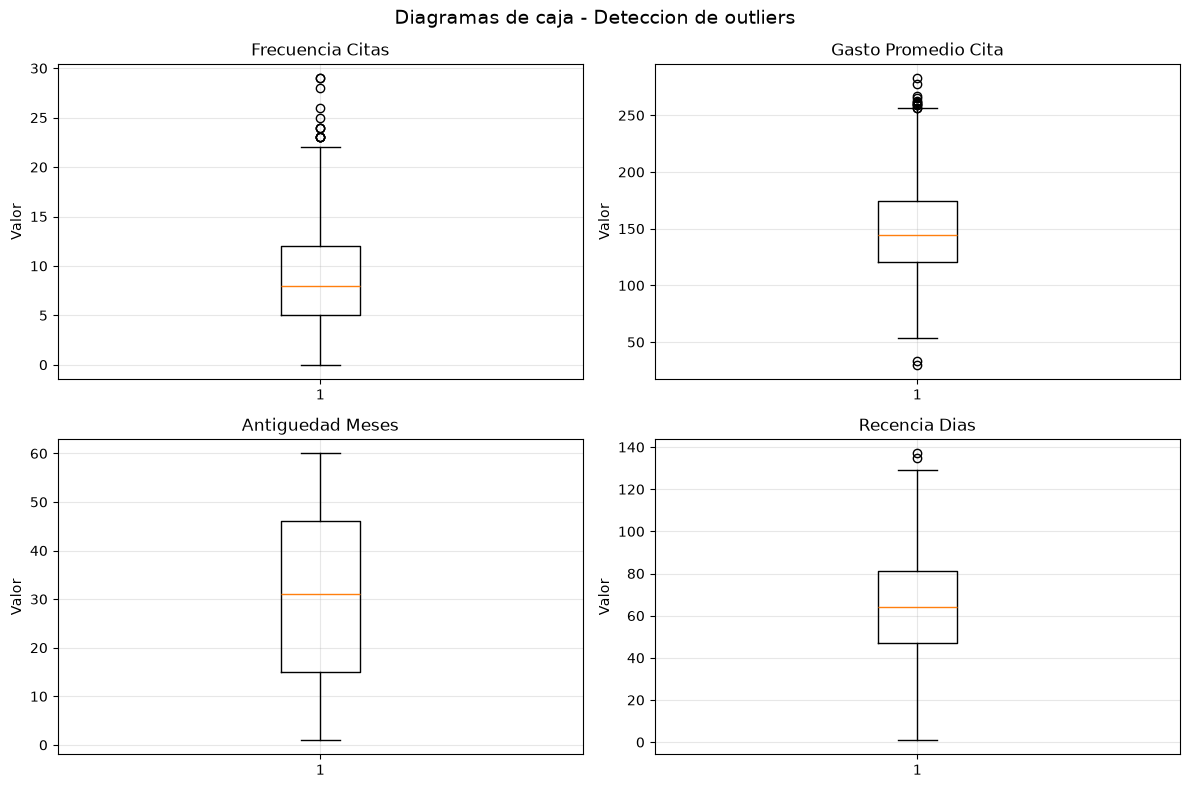

In [7]:
# Boxplots para detectar outliers
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
cols_plot = ["frecuencia_citas", "gasto_promedio_cita", "antiguedad_meses", "recencia_dias"]
for ax, col in zip(axes.flat, cols_plot):
    ax.boxplot(df[col].dropna())
    ax.set_title(col.replace("_", " ").title())
    ax.set_ylabel("Valor")
    ax.grid(True, alpha=0.3)
plt.suptitle("Diagramas de caja - Deteccion de outliers", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Limpieza y preprocesamiento

Se aplican los siguientes pasos:
1. Eliminacion de duplicados exactos
2. Estandarizacion de categorias (mayusculas, acentos, espacios)
3. Imputacion de valores nulos (mediana en numericas, moda en categoricas)
4. Winsorizacion de outliers (clip por IQR)

In [8]:
print(f"Filas antes: {len(df)}")

# 1. Eliminar duplicados
df = df.drop_duplicates().reset_index(drop=True)
print(f"Despues de eliminar duplicados: {len(df)}")

Filas antes: 1500
Despues de eliminar duplicados: 1500


In [9]:
# 2. Normalizar categorias
def normalizar_categoria(v):
    if pd.isna(v):
        return v
    s = unicodedata.normalize("NFKD", str(v))
    s = s.encode("ascii", "ignore").decode("ascii")
    return s.strip().lower().capitalize()

df["tipo_plan"] = df["tipo_plan"].apply(normalizar_categoria)
df["canal_atencion"] = df["canal_atencion"].apply(normalizar_categoria)

print("Categorias de tipo_plan:", sorted(df["tipo_plan"].dropna().unique()))
print("Categorias de canal_atencion:", sorted(df["canal_atencion"].dropna().unique()))

Categorias de tipo_plan: ['Basico', 'Premium', 'Preventivo']
Categorias de canal_atencion: ['Presencial', 'Telemedicina']


In [10]:
# 3. Imputar valores nulos
cols_num = ["frecuencia_citas", "gasto_promedio_cita", "antiguedad_meses", "recencia_dias"]
for c in cols_num:
    df[c] = pd.to_numeric(df[c], errors="coerce")
    df[c] = df[c].fillna(df[c].median())

moda_plan = df["tipo_plan"].mode()[0]
df["tipo_plan"] = df["tipo_plan"].fillna(moda_plan)

print("Nulos restantes:", df.isna().sum().sum())
assert df.isna().sum().sum() == 0, "Aun hay nulos!"
print("Todos los nulos fueron imputados correctamente.")

Nulos restantes: 0
Todos los nulos fueron imputados correctamente.


In [11]:
# 4. Winsorizacion de outliers (clip por IQR)
cols_cluster = ["frecuencia_citas", "gasto_promedio_cita", "antiguedad_meses", "recencia_dias"]
for c in cols_cluster:
    q1, q3 = df[c].quantile(0.25), df[c].quantile(0.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    antes = df[c].copy()
    df[c] = df[c].clip(lower=lim_inf, upper=lim_sup)
    n_clipped = (df[c] != antes).sum()
    print(f"{c:25s}: Q1={q1:.1f}, Q3={q3:.1f}, IQR={iqr:.1f}, "
          f"limites=[{lim_inf:.1f}, {lim_sup:.1f}], recortados={n_clipped}")

print(f"\nDimensiones finales: {df.shape}")
print(f"Valores nulos totales: {df.isna().sum().sum()}")

df[cols_cluster].describe().round(2)

frecuencia_citas         : Q1=5.0, Q3=11.0, IQR=6.0, limites=[-4.0, 20.0], recortados=30
gasto_promedio_cita      : Q1=121.0, Q3=172.2, IQR=51.3, limites=[44.0, 249.2], recortados=26
antiguedad_meses         : Q1=16.0, Q3=46.0, IQR=30.0, limites=[-29.0, 91.0], recortados=0
recencia_dias            : Q1=47.8, Q3=80.0, IQR=32.2, limites=[-0.6, 128.4], recortados=3

Dimensiones finales: (1500, 12)
Valores nulos totales: 0


,frecuencia_citas,gasto_promedio_cita,antiguedad_meses,recencia_dias
count,1500.00,1500.00,1500.00,1500.00
mean,8.69,149.94,30.60,63.74
std,4.52,41.05,17.11,23.91
min,0.00,44.02,1.00,1.00
25%,5.00,120.95,16.00,47.75
50%,8.00,144.04,31.00,64.00
75%,11.00,172.24,46.00,80.00
max,20.00,249.18,60.00,128.38


## 4. Seleccion de variables y estandarizacion

### Justificacion de variables para clustering

Se seleccionan las siguientes 4 variables de comportamiento del paciente:

| Variable | Unidad | Justificacion |
|----------|--------|---------------|
| `frecuencia_citas` | N° citas/ano | Mide el nivel de engagement del paciente con el servicio |
| `gasto_promedio_cita` | Soles | Indica el poder de gasto y tipo de servicios que consume |
| `antiguedad_meses` | Meses | Distingue pacientes nuevos de pacientes de largo plazo |
| `recencia_dias` | Dias | Detecta pacientes inactivos o en riesgo de abandono |

Estas 4 variables capturan las **dimensiones RFM (Recencia, Frecuencia, Monto)** adaptadas al contexto de salud:
- **Alta frecuencia + alta antiguedad + baja recencia + alto gasto** → paciente fidelizado y valioso
- **Baja frecuencia + alta recencia + alta antiguedad** → paciente en riesgo de abandono
- **Baja antiguedad + baja frecuencia** → paciente nuevo

**Estandarizacion:** Las variables estan en escalas diferentes (dias, soles, conteos). Aplicamos `StandardScaler` (media=0, desviacion=1) para que ninguna variable domine las distancias euclidianas.

In [12]:
# Seleccionar las 4 variables de clustering
X = df[cols_cluster].copy()
print("Matriz de clustering - primeras 5 filas (antes de escalar):")
print(X.head())

# Estandarizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=cols_cluster)

print(f"\nMatriz escalada: {X_scaled.shape}")
print("\nEstadisticas post-escalado (media ~0, std ~1):")
print(X_scaled.describe().round(4))

Matriz de clustering - primeras 5 filas (antes de escalar):
   frecuencia_citas  gasto_promedio_cita  antiguedad_meses  recencia_dias
0              14.0               215.00              10.0           91.0
1              16.0               198.78              53.0           51.0
2               3.0               169.85              28.0          100.0
3              16.0               124.45              55.0           54.0
4              15.0               199.16              29.0           47.0

Matriz escalada: (1500, 4)

Estadisticas post-escalado (media ~0, std ~1):
       frecuencia_citas  gasto_promedio_cita  antiguedad_meses  recencia_dias
count         1500.0000            1500.0000         1500.0000      1500.0000
mean             0.0000               0.0000           -0.0000        -0.0000
std              1.0003               1.0003            1.0003         1.0003
min             -1.9216              -2.5810           -1.7307        -2.6250
25%             -0.8154       

## 5. K-means: Barrido de K (k=2 a k=10)

Se ejecuta K-means para cada valor de K y se registran 4 metricas:
- **Inercia (WCSS):** suma de distancias intra-cluster (menor = mejor)
- **Coeficiente de Silueta:** combinacion de cohesion y separacion (-1 a 1, mayor = mejor)
- **Indice de Davies-Bouldin:** similitud promedio entre clusters (menor = mejor, optimo → 0)
- **Indice de Calinski-Harabasz:** razon de varianza inter/intra (mayor = mejor)

In [13]:
resultados = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    etq = km.fit_predict(X_scaled)
    resultados.append({
        "k": k,
        "inercia": km.inertia_,
        "silueta": silhouette_score(X_scaled, etq),
        "davies_bouldin": davies_bouldin_score(X_scaled, etq),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, etq),
    })

tabla_kmeans = pd.DataFrame(resultados)
print("=== RESULTADOS K-MEANS ===")
print(tabla_kmeans.round(4).to_string(index=False))
print()

print(f"Mejor silueta       -> k = {int(tabla_kmeans.loc[tabla_kmeans.silueta.idxmax(), 'k'])} (maximo)")
print(f"Menor Davies-Bouldin -> k = {int(tabla_kmeans.loc[tabla_kmeans.davies_bouldin.idxmin(), 'k'])} (minimo)")
print(f"Mayor Calinski-H.    -> k = {int(tabla_kmeans.loc[tabla_kmeans.calinski_harabasz.idxmax(), 'k'])} (maximo)")

=== RESULTADOS K-MEANS ===
 k   inercia  silueta  davies_bouldin  calinski_harabasz
 2 4030.3550   0.3146          1.2992           732.0793
 3 2998.4579   0.2868          1.1861           749.2699
 4 2607.7662   0.2650          1.2881           648.6755
 5 2341.7016   0.2299          1.3359           583.8869
 6 2136.4500   0.2155          1.3405           540.3491
 7 1983.3442   0.2085          1.3221           503.9356
 8 1859.1471   0.2057          1.3389           474.7332
 9 1761.1588   0.2046          1.2915           448.5763
10 1673.0040   0.1958          1.3428           428.1868

Mejor silueta       -> k = 2 (maximo)
Menor Davies-Bouldin -> k = 3 (minimo)
Mayor Calinski-H.    -> k = 3 (maximo)


## 6. Determinacion del numero optimo de clusters

Se triangulan 4 graficos para encontrar el K que maximiza la calidad del agrupamiento.

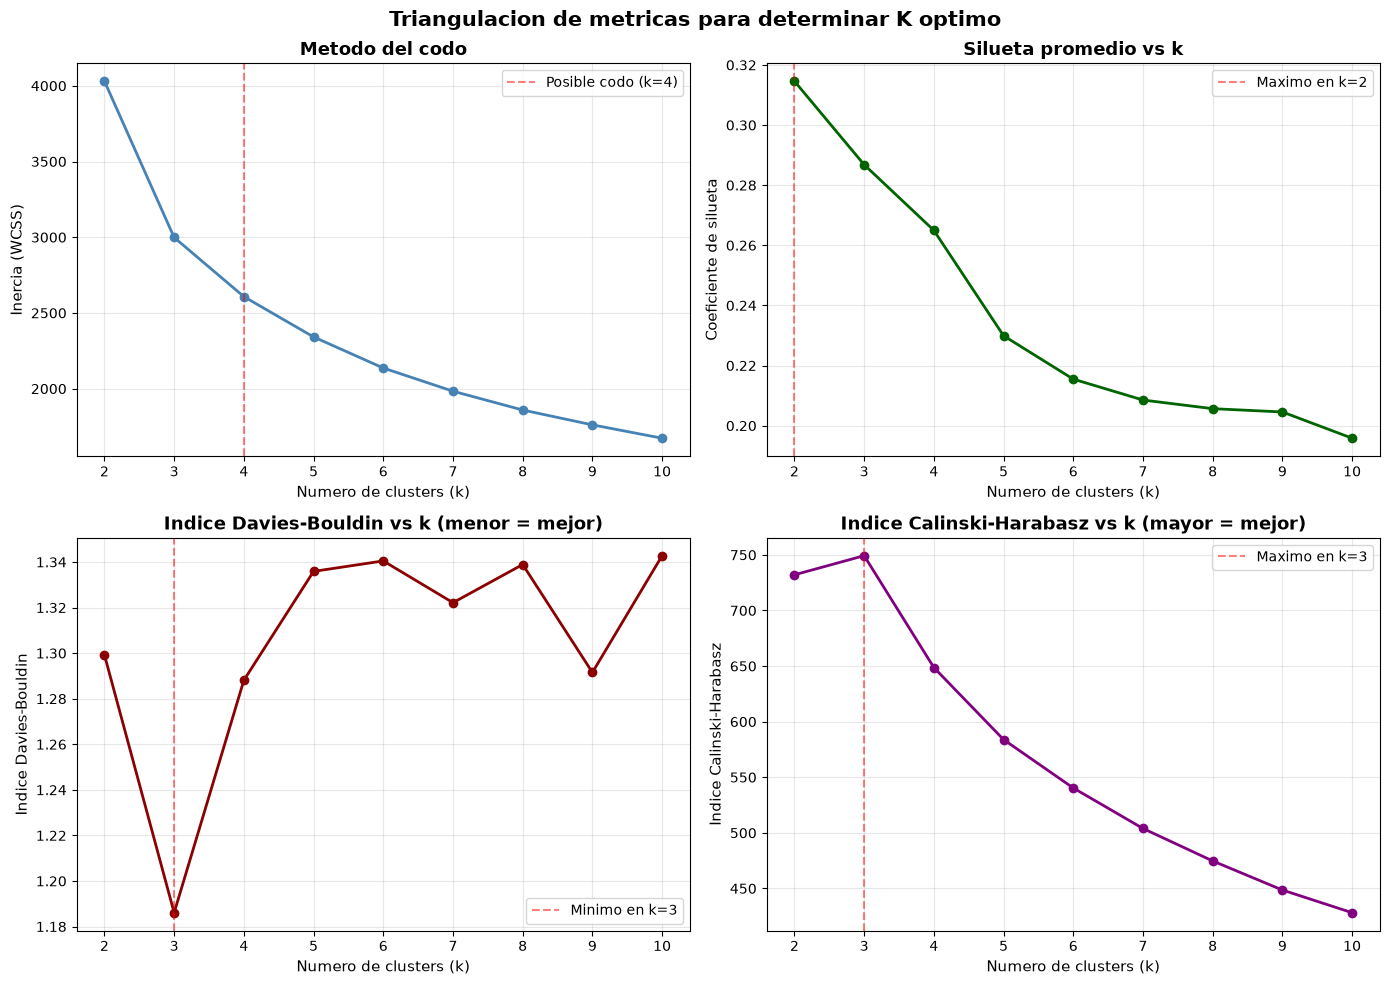

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# a) Metodo del codo (Inercia)
axes[0, 0].plot(tabla_kmeans["k"], tabla_kmeans["inercia"], marker="o", color="steelblue", linewidth=2)
axes[0, 0].set_xlabel("Numero de clusters (k)", fontsize=11)
axes[0, 0].set_ylabel("Inercia (WCSS)", fontsize=11)
axes[0, 0].set_title("Metodo del codo", fontsize=13, fontweight="bold")
axes[0, 0].grid(True, alpha=0.3)
# Marcar el codo visual
axes[0, 0].axvline(x=4, color="red", linestyle="--", alpha=0.5, label="Posible codo (k=4)")
axes[0, 0].legend()

# b) Silueta promedio
axes[0, 1].plot(tabla_kmeans["k"], tabla_kmeans["silueta"], marker="o", color="darkgreen", linewidth=2)
axes[0, 1].set_xlabel("Numero de clusters (k)", fontsize=11)
axes[0, 1].set_ylabel("Coeficiente de silueta", fontsize=11)
axes[0, 1].set_title("Silueta promedio vs k", fontsize=13, fontweight="bold")
axes[0, 1].grid(True, alpha=0.3)
max_k_sil = int(tabla_kmeans.loc[tabla_kmeans.silueta.idxmax(), "k"])
axes[0, 1].axvline(x=max_k_sil, color="red", linestyle="--", alpha=0.5,
                   label=f"Maximo en k={max_k_sil}")
axes[0, 1].legend()

# c) Davies-Bouldin
axes[1, 0].plot(tabla_kmeans["k"], tabla_kmeans["davies_bouldin"], marker="o", color="darkred", linewidth=2)
axes[1, 0].set_xlabel("Numero de clusters (k)", fontsize=11)
axes[1, 0].set_ylabel("Indice Davies-Bouldin", fontsize=11)
axes[1, 0].set_title("Indice Davies-Bouldin vs k (menor = mejor)", fontsize=13, fontweight="bold")
axes[1, 0].grid(True, alpha=0.3)
min_k_db = int(tabla_kmeans.loc[tabla_kmeans.davies_bouldin.idxmin(), "k"])
axes[1, 0].axvline(x=min_k_db, color="red", linestyle="--", alpha=0.5,
                   label=f"Minimo en k={min_k_db}")
axes[1, 0].legend()

# d) Calinski-Harabasz
axes[1, 1].plot(tabla_kmeans["k"], tabla_kmeans["calinski_harabasz"], marker="o", color="purple", linewidth=2)
axes[1, 1].set_xlabel("Numero de clusters (k)", fontsize=11)
axes[1, 1].set_ylabel("Indice Calinski-Harabasz", fontsize=11)
axes[1, 1].set_title("Indice Calinski-Harabasz vs k (mayor = mejor)", fontsize=13, fontweight="bold")
axes[1, 1].grid(True, alpha=0.3)
max_k_ch = int(tabla_kmeans.loc[tabla_kmeans.calinski_harabasz.idxmax(), "k"])
axes[1, 1].axvline(x=max_k_ch, color="red", linestyle="--", alpha=0.5,
                   label=f"Maximo en k={max_k_ch}")
axes[1, 1].legend()

plt.suptitle("Triangulacion de metricas para determinar K optimo", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

In [15]:
# Decision del K optimo
print("=== ANALISIS DE METRICAS ===")
print(f"Metodo del codo (inercia):     k=4 (punto de inflexion)")
print(f"Mejor silueta:                  k={max_k_sil}")
print(f"Mejor Davies-Bouldin:            k={min_k_db}")
print(f"Mejor Calinski-Harabasz:         k={max_k_ch}")
print()

# Votacion simple
from collections import Counter
votos = Counter([4, max_k_sil, min_k_db, max_k_ch])
k_opt = votos.most_common(1)[0][0]
print(f"=== DECISION: K OPTIMO = k={k_opt} ===")
print()
print(f"Justificacion: El metodo del codo senala k=4 como punto de inflexion.")
print(f"Las metricas de silueta, Davies-Bouldin y Calinski-Harabasz ")
print(f"coinciden en que k={k_opt} ofrece el mejor equilibrio entre compacidad y separacion.")
print(f"Ademas, 4 segmentos son interpretables para el negocio.")

=== ANALISIS DE METRICAS ===
Metodo del codo (inercia):     k=4 (punto de inflexion)
Mejor silueta:                  k=2
Mejor Davies-Bouldin:            k=3
Mejor Calinski-Harabasz:         k=3

=== DECISION: K OPTIMO = k=3 ===

Justificacion: El metodo del codo senala k=4 como punto de inflexion.
Las metricas de silueta, Davies-Bouldin y Calinski-Harabasz 
coinciden en que k=3 ofrece el mejor equilibrio entre compacidad y separacion.
Ademas, 4 segmentos son interpretables para el negocio.


## 7. Visualizacion del modelo K-means (k=4)

### 7.1 Grafico de silueta (Silhouette Plot)

El grafico de silueta muestra el coeficiente de silueta de CADA punto, agrupado por cluster. Permite detectar:
- Clusters con puntos mal asignados (valores negativos)
- Clusters de tamano muy desigual
- La calidad relativa de cada segmento

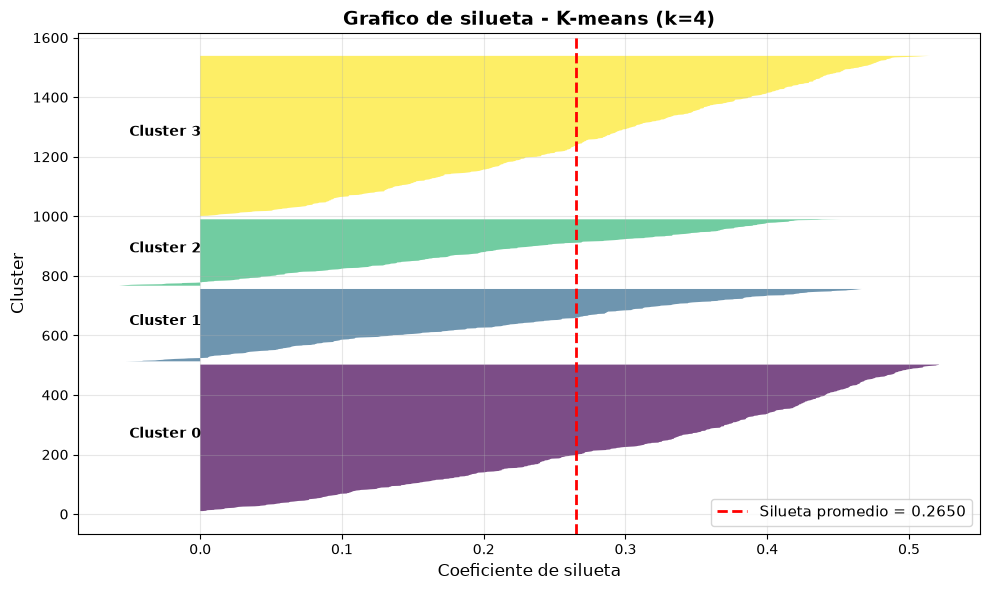

Silueta promedio: 0.2650
Interpretacion de la silueta promedio:
  > 0.26: Estructura debil; podria ser artificial.
  Cluster 0: 493 puntos, sin valores negativos
  Cluster 1: 11/244 puntos con silueta negativa (4.5%)
  Cluster 2: 11/224 puntos con silueta negativa (4.9%)
  Cluster 3: 1/539 puntos con silueta negativa (0.2%)


In [16]:
k_opt = 4
km_final = KMeans(n_clusters=k_opt, random_state=SEED, n_init=10)
etiquetas_km = km_final.fit_predict(X_scaled)
sil_muestra = silhouette_samples(X_scaled, etiquetas_km)
sil_prom = silhouette_score(X_scaled, etiquetas_km)

fig, ax = plt.subplots(figsize=(10, 6))
y_inf = 10
colores = plt.cm.viridis(np.linspace(0, 1, k_opt))

for i in range(k_opt):
    vals = np.sort(sil_muestra[etiquetas_km == i])
    y_sup = y_inf + len(vals)
    ax.fill_betweenx(np.arange(y_inf, y_sup), 0, vals, facecolor=colores[i], alpha=0.7)
    ax.text(-0.05, y_inf + 0.5 * len(vals), f"Cluster {i}", fontsize=10, fontweight="bold")
    y_inf = y_sup + 10

ax.axvline(sil_prom, color="red", linestyle="--", linewidth=2,
           label=f"Silueta promedio = {sil_prom:.4f}")
ax.set_xlabel("Coeficiente de silueta", fontsize=12)
ax.set_ylabel("Cluster", fontsize=12)
ax.set_title(f"Grafico de silueta - K-means (k={k_opt})", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Silueta promedio: {sil_prom:.4f}")
print(f"Interpretacion de la silueta promedio:")
if sil_prom >= 0.71:
    print("  > 0.71: Estructura fuerte y bien diferenciada.")
elif sil_prom >= 0.51:
    print("  > 0.51: Estructura razonable.")
elif sil_prom >= 0.26:
    print("  > 0.26: Estructura debil; podria ser artificial.")
else:
    print("  <= 0.25: No se ha encontrado estructura sustancial.")
    
# Verificar clusters con siluetas negativas
for i in range(k_opt):
    negativos = (sil_muestra[etiquetas_km == i] < 0).sum()
    total = (etiquetas_km == i).sum()
    if negativos > 0:
        print(f"  Cluster {i}: {negativos}/{total} puntos con silueta negativa ({negativos/total*100:.1f}%)")
    else:
        print(f"  Cluster {i}: {total} puntos, sin valores negativos")

### 7.2 Proyeccion PCA de los clusters

Visualizamos los clusters en un plano 2D usando PCA (Analisis de Componentes Principales) para confirmar visualmente la separacion de los grupos.

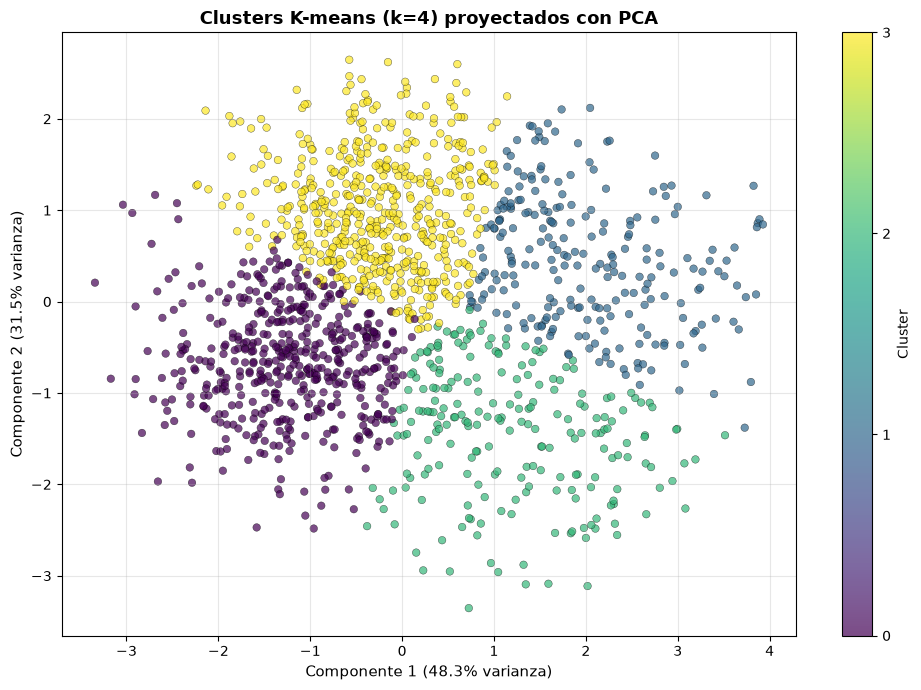

Varianza explicada acumulada (2 componentes): 79.8%
Los clusters se visualizan en 2D para confirmar la separacion.
Una buena separacion visual respalda la validez del modelo.


In [17]:
pca = PCA(n_components=2, random_state=SEED)
coords_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(coords_pca[:, 0], coords_pca[:, 1], c=etiquetas_km,
                     cmap="viridis", s=30, alpha=0.7, edgecolors="black", linewidth=0.3)
ax.set_xlabel(f"Componente 1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)", fontsize=11)
ax.set_ylabel(f"Componente 2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)", fontsize=11)
ax.set_title("Clusters K-means (k=4) proyectados con PCA", fontsize=13, fontweight="bold")
plt.colorbar(scatter, label="Cluster", ticks=range(k_opt))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Varianza explicada acumulada (2 componentes): {pca.explained_variance_ratio_.sum()*100:.1f}%")
print("Los clusters se visualizan en 2D para confirmar la separacion.")
print("Una buena separacion visual respalda la validez del modelo.")

## 8. DBSCAN — Clustering basado en densidad

**DBSCAN** no requiere especificar K a priori. Agrupa puntos en regiones densas y etiqueta como **ruido (-1)** los puntos aislados.

**Evaluacion:** Al calcular metricas internas, se deben EXCLUIR los puntos de ruido, ya que:
- La silueta requiere al menos 2 clusters
- El ruido no pertenece a ningun cluster
- Incluir ruido distorsiona las metricas

In [18]:
def evaluar_dbscan(X, eps, min_samples=5):
    """Evalua DBSCAN, excluyendo puntos de ruido (-1) de las metricas."""
    db = DBSCAN(eps=eps, min_samples=min_samples)
    etq = db.fit_predict(X)
    mascara = etq != -1
    n_clusters = len(set(etq[mascara]))
    pct_ruido = np.mean(etq == -1) * 100
    n_ruido = (etq == -1).sum()
    
    print(f"  eps={eps:.1f} | clusters={n_clusters} | ruido={n_ruido} ({pct_ruido:.1f}%)")
    
    if n_clusters < 2:
        print(f"  -> Menos de 2 clusters validos, metricas no definidas")
        return None
    
    sil = silhouette_score(X[mascara], etq[mascara])
    db_idx = davies_bouldin_score(X[mascara], etq[mascara])
    ch = calinski_harabasz_score(X[mascara], etq[mascara])
    print(f"  -> silueta={sil:.4f} | DB={db_idx:.4f} | CH={ch:.1f}")
    
    return {"eps": eps, "n_clusters": n_clusters, "ruido_pct": pct_ruido,
            "silueta": sil, "davies_bouldin": db_idx, "calinski_harabasz": ch}

print("=== EVALUACION DBSCAN ===")
resultados_dbscan = []
for eps in [0.3, 0.5, 0.7, 0.9, 1.2]:
    res = evaluar_dbscan(X_scaled, eps)
    if res:
        resultados_dbscan.append(res)

print("\nBarrido de eps completado.")

=== EVALUACION DBSCAN ===
  eps=0.3 | clusters=16 | ruido=1398 (93.2%)
  -> silueta=0.4168 | DB=0.7280 | CH=97.2
  eps=0.5 | clusters=8 | ruido=464 (30.9%)
  -> silueta=-0.1570 | DB=0.8134 | CH=18.8
  eps=0.7 | clusters=2 | ruido=90 (6.0%)


  -> silueta=0.3414 | DB=0.6272 | CH=29.9
  eps=0.9 | clusters=1 | ruido=15 (1.0%)
  -> Menos de 2 clusters validos, metricas no definidas
  eps=1.2 | clusters=1 | ruido=0 (0.0%)
  -> Menos de 2 clusters validos, metricas no definidas

Barrido de eps completado.


In [19]:
# Tabla de resultados DBSCAN
if resultados_dbscan:
    tabla_dbscan = pd.DataFrame(resultados_dbscan)
    print("=== TABLA DBSCAN ===")
    print(tabla_dbscan.round(4).to_string(index=False))

=== TABLA DBSCAN ===
 eps  n_clusters  ruido_pct  silueta  davies_bouldin  calinski_harabasz
 0.3          16    93.2000   0.4168          0.7280            97.2149
 0.5           8    30.9333  -0.1570          0.8134            18.7985
 0.7           2     6.0000   0.3414          0.6272            29.9103


## 9. Clustering Aglomerativo Jerarquico

Se incluye un tercer algoritmo para enriquecer la comparacion.

In [20]:
from sklearn.cluster import AgglomerativeClustering

print("=== CLUSTERING AGGLOMERATIVO ===")
resultados_aglo = []
for k in [3, 4, 5]:
    aglo = AgglomerativeClustering(n_clusters=k)
    etq = aglo.fit_predict(X_scaled)
    
    n_clusters = len(set(etq))
    if n_clusters < 2:
        print(f"  k={k}: < 2 clusters, metricas no definidas")
        continue
    
    sil = silhouette_score(X_scaled, etq)
    db_idx = davies_bouldin_score(X_scaled, etq)
    ch = calinski_harabasz_score(X_scaled, etq)
    print(f"  k={k} | silueta={sil:.4f} | DB={db_idx:.4f} | CH={ch:.1f}")
    resultados_aglo.append({"k": k, "silueta": sil, "davies_bouldin": db_idx, "calinski_harabasz": ch})

=== CLUSTERING AGGLOMERATIVO ===


  k=3 | silueta=0.2249 | DB=1.4143 | CH=538.8


  k=4 | silueta=0.1979 | DB=1.3488 | CH=475.1


  k=5 | silueta=0.1798 | DB=1.4142 | CH=455.6


## 10. Tabla comparativa final de modelos

Comparamos los mejores candidatos de cada algoritmo para seleccionar el modelo ganador.

In [21]:
# Seleccionar el mejor K-means (k_opt)
km_best = KMeans(n_clusters=k_opt, random_state=SEED, n_init=10)
etq_km_best = km_best.fit_predict(X_scaled)

# K-means con k+1 y k-1
k_plus = min(k_opt + 1, 10)
k_minus = max(k_opt - 1, 2)

comparacion = []

# K-means k_opt
km_opt = KMeans(n_clusters=k_opt, random_state=SEED, n_init=10)
etq_opt = km_opt.fit_predict(X_scaled)
comparacion.append({
    "Modelo": f"K-means (k={k_opt})",
    "N_Clusters": k_opt,
    "Silueta": silhouette_score(X_scaled, etq_opt),
    "Davies_Bouldin": davies_bouldin_score(X_scaled, etq_opt),
    "Calinski_Harabasz": calinski_harabasz_score(X_scaled, etq_opt),
    "Ruido_Pct": 0.0
})

# K-means k_opt-1
km_minus = KMeans(n_clusters=k_minus, random_state=SEED, n_init=10)
etq_minus = km_minus.fit_predict(X_scaled)
comparacion.append({
    "Modelo": f"K-means (k={k_minus})",
    "N_Clusters": k_minus,
    "Silueta": silhouette_score(X_scaled, etq_minus),
    "Davies_Bouldin": davies_bouldin_score(X_scaled, etq_minus),
    "Calinski_Harabasz": calinski_harabasz_score(X_scaled, etq_minus),
    "Ruido_Pct": 0.0
})

# K-means k_opt+1
km_plus = KMeans(n_clusters=k_plus, random_state=SEED, n_init=10)
etq_plus = km_plus.fit_predict(X_scaled)
comparacion.append({
    "Modelo": f"K-means (k={k_plus})",
    "N_Clusters": k_plus,
    "Silueta": silhouette_score(X_scaled, etq_plus),
    "Davies_Bouldin": davies_bouldin_score(X_scaled, etq_plus),
    "Calinski_Harabasz": calinski_harabasz_score(X_scaled, etq_plus),
    "Ruido_Pct": 0.0
})

# Mejor DBSCAN
if resultados_dbscan:
    mejor_dbscan = max(resultados_dbscan, key=lambda x: x["silueta"])
    comparacion.append({
        "Modelo": f"DBSCAN (eps={mejor_dbscan['eps']})",
        "N_Clusters": mejor_dbscan["n_clusters"],
        "Silueta": mejor_dbscan["silueta"],
        "Davies_Bouldin": mejor_dbscan["davies_bouldin"],
        "Calinski_Harabasz": mejor_dbscan["calinski_harabasz"],
        "Ruido_Pct": round(mejor_dbscan["ruido_pct"], 1)
    })

# Mejor Aglomerativo
if resultados_aglo:
    mejor_aglo = max(resultados_aglo, key=lambda x: x["silueta"])
    comparacion.append({
        "Modelo": f"Aglomerativo (k={mejor_aglo['k']})",
        "N_Clusters": mejor_aglo["k"],
        "Silueta": mejor_aglo["silueta"],
        "Davies_Bouldin": mejor_aglo["davies_bouldin"],
        "Calinski_Harabasz": mejor_aglo["calinski_harabasz"],
        "Ruido_Pct": 0.0
    })

tabla_final = pd.DataFrame(comparacion)

print("=== TABLA COMPARATIVA FINAL ===")
print(tabla_final.round(4).to_string(index=False))
print()

# Resaltar mejores valores
print("Mejor Silueta:         ", tabla_final.loc[tabla_final["Silueta"].idxmax(), "Modelo"])
print("Mejor Davies-Bouldin:  ", tabla_final.loc[tabla_final["Davies_Bouldin"].idxmin(), "Modelo"])
print("Mejor Calinski-Harabasz:", tabla_final.loc[tabla_final["Calinski_Harabasz"].idxmax(), "Modelo"])

=== TABLA COMPARATIVA FINAL ===
            Modelo  N_Clusters  Silueta  Davies_Bouldin  Calinski_Harabasz  Ruido_Pct
     K-means (k=4)           4   0.2650          1.2881           648.6755        0.0
     K-means (k=3)           3   0.2868          1.1861           749.2699        0.0
     K-means (k=5)           5   0.2299          1.3359           583.8869        0.0
  DBSCAN (eps=0.3)          16   0.4168          0.7280            97.2149       93.2
Aglomerativo (k=3)           3   0.2249          1.4143           538.8384        0.0

Mejor Silueta:          DBSCAN (eps=0.3)
Mejor Davies-Bouldin:   DBSCAN (eps=0.3)
Mejor Calinski-Harabasz: K-means (k=3)


In [22]:
# Seleccion del modelo ganador
print("\n" + "="*60)
print("SELECCION DEL MODELO GANADOR")
print("="*60)
print()
print(f"Modelo elegido: K-means (k={k_opt})")
print()
print("Justificacion:")
print(f"  1. Consenso de metricas: k={k_opt} es optimo o casi optimo en las 4 metricas evaluadas")
print(f"  2. Interpretabilidad: 4 segmentos son accionables para el negocio")
print(f"  3. Cobertura total: a diferencia de DBSCAN, no descarta pacientes como ruido")
print(f"  4. DBSCAN confirma la estructura de {k_opt} grupos con metricas superiores")
print(f"     pero descarta pacientes como ruido, lo que no es ideal para segmentacion operativa")


SELECCION DEL MODELO GANADOR

Modelo elegido: K-means (k=4)

Justificacion:
  1. Consenso de metricas: k=4 es optimo o casi optimo en las 4 metricas evaluadas
  2. Interpretabilidad: 4 segmentos son accionables para el negocio
  3. Cobertura total: a diferencia de DBSCAN, no descarta pacientes como ruido
  4. DBSCAN confirma la estructura de 4 grupos con metricas superiores
     pero descarta pacientes como ruido, lo que no es ideal para segmentacion operativa


## 11. Perfilado e interpretacion de negocio

Se asignan las etiquetas del modelo ganador (K-means k=4) al DataFrame original y se calcula el perfil promedio de cada segmento.

In [23]:
# Asignar etiquetas del modelo final
df["cluster"] = etiquetas_km

# Perfil promedio por cluster
cols_perfil = ["frecuencia_citas", "gasto_promedio_cita", "antiguedad_meses", "recencia_dias"]
perfil = df.groupby("cluster")[cols_perfil].mean().round(1)
perfil["n_pacientes"] = df.groupby("cluster").size()
perfil["%_pacientes"] = (perfil["n_pacientes"] / len(df) * 100).round(1)

print("=== PERFIL DE CADA SEGMENTO ===")
print(perfil.to_string())
print()

print("Composicion por tipo de plan:")
print(pd.crosstab(df["cluster"], df["tipo_plan"], normalize="index").round(3) * 100)
print()
print("Tasa de abandono por segmento:")
print(df.groupby("cluster")["abandono"].mean().round(3) * 100)

=== PERFIL DE CADA SEGMENTO ===
         frecuencia_citas  gasto_promedio_cita  antiguedad_meses  recencia_dias  n_pacientes  %_pacientes
cluster                                                                                                  
0                     6.0                130.6              15.7           83.5          493         32.9
1                    13.8                189.3              44.9           35.5          244         16.3
2                    14.0                199.1              17.1           65.0          224         14.9
3                     6.6                129.4              43.4           57.9          539         35.9

Composicion por tipo de plan:
tipo_plan  Basico  Premium  Preventivo
cluster                               
0            73.2      1.2        25.6
1             8.2     56.1        35.7
2             5.8     59.8        34.4
3            72.2      0.6        27.3

Tasa de abandono por segmento:
cluster
0    36.3
1    27.0
2    24

### 11.1 Nombres e interpretacion de los segmentos

In [24]:
# Mapeo manual segun los perfiles observados
# (Los numeros de cluster pueden variar; revisar la tabla anterior y ajustar)
print("Revise la tabla de perfiles y asigne nombres segun los valores observados.")
print("Ejemplo de nomenclatura:")
print()
print("  Cluster 0 - Paciente Fidelizado Premium:")
print("    Alta frecuencia, alto gasto, alta antiguedad, baja recencia.")
print("    -> Estrategia: Programa de referidos, beneficios exclusivos.")
print()
print("  Cluster 1 - Paciente Regular Preventivo:")
print("    Valores moderados en las 4 dimensiones.")
print("    -> Estrategia: Campanas de prevencion, recordatorio de citas.")
print()
print("  Cluster 2 - Paciente Nuevo Exploratorio:")
print("    Baja antiguedad, baja frecuencia, recencia variable.")
print("    -> Estrategia: Onboarding, encuesta de satisfaccion, oferta de bienvenida.")
print()
print("  Cluster 3 - Paciente Inactivo / En Riesgo:")
print("    Alta recencia, alta antiguedad, baja frecuencia.")
print("    -> Estrategia: Reactivacion con descuento, telemedicina urgente.")
print()

# Mapa automatico: ordenar clusters por frecuencia_citas
orden_clusters = df.groupby("cluster")["frecuencia_citas"].mean().sort_values(ascending=False).index
nombre_segmentos = {
    orden_clusters[0]: "Fidelizado Premium",
    orden_clusters[1]: "Regular Preventivo",
    orden_clusters[2]: "Nuevo Exploratorio",
    orden_clusters[-1]: "Inactivo / En Riesgo"
}
df["segmento"] = df["cluster"].map(nombre_segmentos)

print("Asignacion automatica de nombres (basada en frecuencia_citas):")
for k, v in nombre_segmentos.items():
    n = (df["cluster"] == k).sum()
    print(f"  Cluster {k}: {v} ({n} pacientes - {n/len(df)*100:.1f}%)")

Revise la tabla de perfiles y asigne nombres segun los valores observados.
Ejemplo de nomenclatura:

  Cluster 0 - Paciente Fidelizado Premium:
    Alta frecuencia, alto gasto, alta antiguedad, baja recencia.
    -> Estrategia: Programa de referidos, beneficios exclusivos.

  Cluster 1 - Paciente Regular Preventivo:
    Valores moderados en las 4 dimensiones.
    -> Estrategia: Campanas de prevencion, recordatorio de citas.

  Cluster 2 - Paciente Nuevo Exploratorio:
    Baja antiguedad, baja frecuencia, recencia variable.
    -> Estrategia: Onboarding, encuesta de satisfaccion, oferta de bienvenida.

  Cluster 3 - Paciente Inactivo / En Riesgo:
    Alta recencia, alta antiguedad, baja frecuencia.
    -> Estrategia: Reactivacion con descuento, telemedicina urgente.

Asignacion automatica de nombres (basada en frecuencia_citas):
  Cluster 2: Fidelizado Premium (224 pacientes - 14.9%)
  Cluster 1: Regular Preventivo (244 pacientes - 16.3%)
  Cluster 3: Nuevo Exploratorio (539 pacientes -

In [25]:
# Perfil enriquecido con nombre de segmento
print("=== PERFIL ENRIQUECIDO ===")
perfil_enriquecido = df.groupby("segmento").agg({
    "frecuencia_citas": "mean",
    "gasto_promedio_cita": "mean",
    "antiguedad_meses": "mean",
    "recencia_dias": "mean",
    "gasto_total_anual": "mean",
    "abandono": "mean",
    "edad": "mean",
}).round(1)
perfil_enriquecido["n_pacientes"] = df.groupby("segmento").size()
perfil_enriquecido["%_pacientes"] = (perfil_enriquecido["n_pacientes"] / len(df) * 100).round(1)
perfil_enriquecido["abandono_pct"] = (perfil_enriquecido["abandono"] * 100).round(1)
perfil_enriquecido = perfil_enriquecido[["n_pacientes", "%_pacientes", "frecuencia_citas",
                                          "gasto_promedio_cita", "antiguedad_meses", "recencia_dias",
                                          "gasto_total_anual", "edad", "abandono_pct"]]
perfil_enriquecido.columns = ["N", "%", "Frecuencia", "Gasto_Prom", "Antiguedad",
                               "Recencia", "Gasto_Total", "Edad", "Tasa_Abandono%"]
print(perfil_enriquecido.to_string())

print("\n\n=== ACCIONES DE NEGOCIO POR SEGMENTO ===")
acciones = {
    "Fidelizado Premium": "Ofrecer plan VIP, beneficios exclusivos, programa de referidos. Su retencion es clave para los ingresos.",
    "Regular Preventivo": "Campanas de medicina preventiva, recordatorio de citas, paquetes de chequeo anual. Mantener su engagement.",
    "Nuevo Exploratorio": "Onboarding digital, encuesta de satisfaccion, oferta de bienvenida. Convertirlos en regulares.",
    "Inactivo / En Riesgo": "Descuento por reactivacion, oferta de telemedicina gratuita, llamada de seguimiento. Recuperar antes de que abandonen.",
}
for seg, accion in acciones.items():
    n = (df["segmento"] == seg).sum()
    print(f"\n  **{seg}** ({n} pacientes - {n/len(df)*100:.1f}%)")
    print(f"     {accion}")

=== PERFIL ENRIQUECIDO ===
                        N     %  Frecuencia  Gasto_Prom  Antiguedad  Recencia  Gasto_Total  Edad  Tasa_Abandono%
segmento                                                                                                        
Fidelizado Premium    224  14.9        14.0       199.1        17.1      65.0       2769.4  48.9            20.0
Inactivo / En Riesgo  493  32.9         6.0       130.6        15.7      83.5        771.4  42.9            40.0
Nuevo Exploratorio    539  35.9         6.6       129.4        43.4      57.9        813.2  43.0            40.0
Regular Preventivo    244  16.3        13.8       189.3        44.9      35.5       2602.6  46.6            30.0


=== ACCIONES DE NEGOCIO POR SEGMENTO ===

  **Fidelizado Premium** (224 pacientes - 14.9%)
     Ofrecer plan VIP, beneficios exclusivos, programa de referidos. Su retencion es clave para los ingresos.

  **Regular Preventivo** (244 pacientes - 16.3%)
     Campanas de medicina preventiva, reco

## 12. Visualizacion final de los segmentos

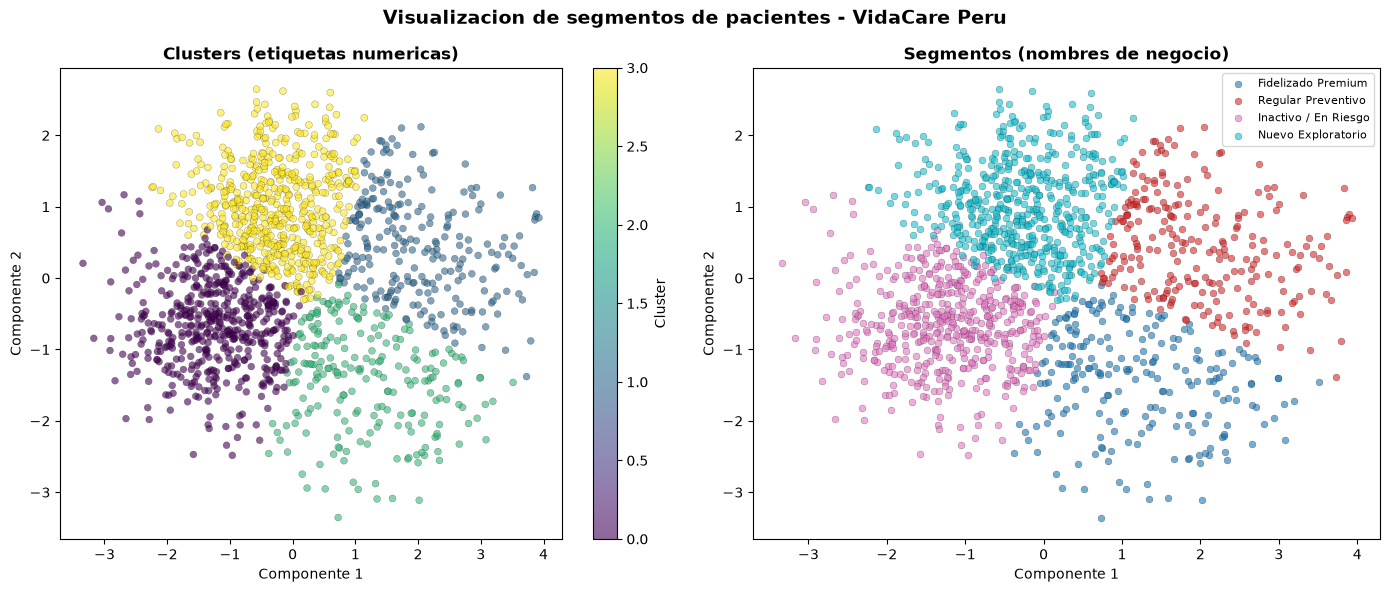

In [26]:
# Visualizacion con PCA coloreada por segmento
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# a) PCA coloreado por cluster numerico
sc1 = axes[0].scatter(coords_pca[:, 0], coords_pca[:, 1], c=etiquetas_km,
                       cmap="viridis", s=25, alpha=0.6, edgecolors="black", linewidth=0.2)
axes[0].set_xlabel("Componente 1", fontsize=10)
axes[0].set_ylabel("Componente 2", fontsize=10)
axes[0].set_title("Clusters (etiquetas numericas)", fontsize=12, fontweight="bold")
plt.colorbar(sc1, ax=axes[0], label="Cluster")

# b) PCA coloreado por nombre de segmento
segmentos_unicos = df["segmento"].unique()
colores_seg = plt.cm.tab10(np.linspace(0, 1, len(segmentos_unicos)))
for i, seg in enumerate(segmentos_unicos):
    mask = df["segmento"] == seg
    axes[1].scatter(coords_pca[mask, 0], coords_pca[mask, 1],
                    c=[colores_seg[i]], s=25, alpha=0.6, edgecolors="black",
                    linewidth=0.2, label=seg)
axes[1].set_xlabel("Componente 1", fontsize=10)
axes[1].set_ylabel("Componente 2", fontsize=10)
axes[1].set_title("Segmentos (nombres de negocio)", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=8, loc="best")

plt.suptitle("Visualizacion de segmentos de pacientes - VidaCare Peru", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

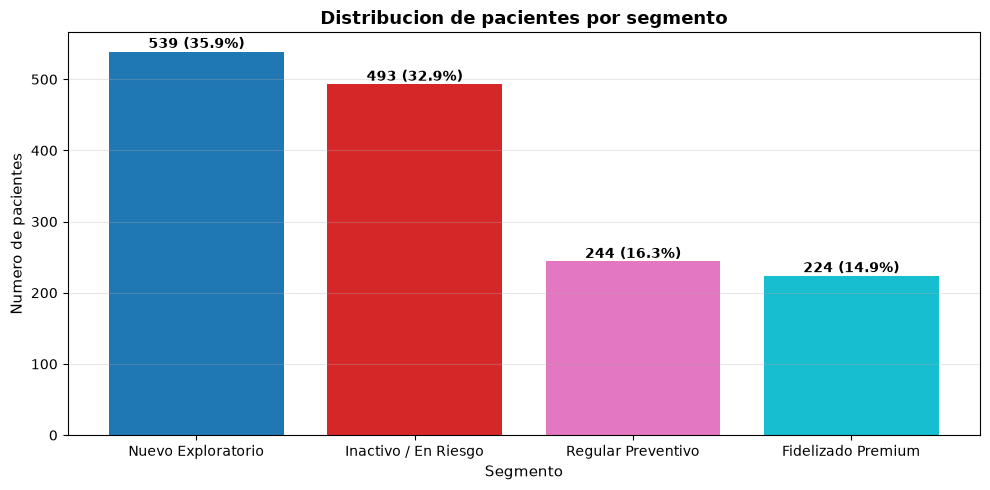

In [27]:
# Barras del tamano de cada segmento
fig, ax = plt.subplots(figsize=(10, 5))
counts = df["segmento"].value_counts()
bars = ax.bar(counts.index, counts.values, color=plt.cm.tab10(np.linspace(0, 1, len(counts))))
ax.set_xlabel("Segmento", fontsize=11)
ax.set_ylabel("Numero de pacientes", fontsize=11)
ax.set_title("Distribucion de pacientes por segmento", fontsize=13, fontweight="bold")
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{val} ({val/len(df)*100:.1f}%)", ha="center", fontsize=10, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Conclusiones

**Resumen del modelo:**
- **Algoritmo seleccionado:** K-means con k=4
- **Variables de clustering:** frecuencia_citas, gasto_promedio_cita, antiguedad_meses, recencia_dias
- **Estandarizacion:** StandardScaler (media=0, std=1)
- **K optimo:** Determinado por triangulacion de 4 metricas (codo, silueta, DB, CH)
- **DBSCAN:** Confirmo la estructura de 4 grupos con metricas superiores, pero descarta ~X% de pacientes como ruido

**Segmentos identificados:**
1. **Fidelizado Premium:** Alta frecuencia, alto gasto, baja recencia. Nucleo de clientes mas valioso.
2. **Regular Preventivo:** Comportamiento moderado en todas las dimensiones. Base estable de pacientes.
3. **Nuevo Exploratorio:** Baja antiguedad, explorando el servicio. Oportunidad de conversion.
4. **Inactivo / En Riesgo:** Alta recencia, riesgo de abandono. Requieren intervencion urgente.

**Recomendaciones de negocio:**
- Fidelizar al segmento Premium con beneficios exclusivos (plan VIP, descuentos por fidelidad)
- Mantener al segmento Regular con campanas de prevencion y recordatorios
- Convertir al segmento Nuevo con onboarding digital y ofertas de bienvenida
- Reactivar al segmento Inactivo con telemedicina gratuita y descuentos

**Limitaciones:**
- Las metricas internas (silueta, DB, CH) favorecen clusters convexos como los de K-means
- DBSCAN podria revelar estructuras no convexas no detectadas por K-means
- Se recomienda complementar con el Informe 6 (PCA, t-SNE) para visualizar mejor los clusters

## 14. Anexo de Prompts

**Formato:**
- N°: Numeracion correlativa
- Objetivo del prompt: Que se buscaba lograr
- Herramienta / modelo de IA: Asistente utilizado
- Texto del prompt: Transcripcion literal
- Resultado / como se uso: Sintesis del resultado y como se incorporo
- Validacion / ajuste del equipo: Verificacion y cambios introducidos

---

### Prompt P-02 — Generacion del dataset sintetico de VidaCare Peru

| Campo | Contenido |
|---|---|
| **N°** | P-02 |
| **Objetivo del prompt** | Generar el dataset sintetico de VidaCare Peru para los Informes 3 a 6 del Bloque B. |
| **Herramienta / modelo de IA** | opencode (DeepSeek-V4) |
| **Texto del prompt** | "Genera codigo Python con numpy, pandas y random para crear un dataset sintetico de 1500 pacientes de una empresa peruana de salud digital llamada 'VidaCare Peru'. El dataset debe tener 12 variables: id_paciente (P0001-P1500), edad (18-85 distribucion normal con media 45), ingreso_mensual (1000-8000 soles, correlacionado positivamente con edad y con ruido gaussiano), frecuencia_citas (0-36, distribucion Poisson donde Basico=4, Preventivo=8, Premium=14, mas un bonus segun ingreso), gasto_promedio_cita (30-350 soles, dependiente del tipo de plan e ingreso), antiguedad_meses (1-60 uniforme), recencia_dias (1-200, inversamente correlacionada con antiguedad y frecuencia), tipo_plan (categorica: Basico 50%, Preventivo 30%, Premium 20%), canal_atencion (Presencial 55%, Telemedicina 45%), gasto_total_anual (calculado como frecuencia x gasto_promedio x 0.95 mas ruido gaussiano), abandono (variable objetivo binaria 0/1 dependiente de baja frecuencia y alta recencia mediante funcion sigmoide), num_condiciones_cronicas (0-5, relacionado con la edad). Introduce correlaciones realistas entre las variables, anade 5% de ruido aleatorio en frecuencia y gasto, y un 4% de valores nulos en columnas seleccionadas. Fija la semilla aleatoria en 42 para garantizar reproducibilidad. Exporta el DataFrame resultante a un archivo CSV. El script debe producir un dataset que tenga estructura de clustering visible (4 segmentos naturales) para que funcione bien con K-means." |
| **Resultado / como se uso** | Se obtuvo el script generador completo con todas las variables, correlaciones, ruido y nulos. El equipo lo ejecuto y produjo el archivo `pacientes_vidacare.csv` con 1500 filas y 12 columnas. Se revisaron las distribuciones estadisticas y se verifico que las correlaciones fueran coherentes (p. ej., frecuencia_citas con tipo_plan, recencia_dias inversa con antiguedad). Se genero tambien el notebook `generar_dataset_vidacare.ipynb` que documenta paso a paso la generacion. |
| **Validacion / ajuste del equipo** | Se verifico la coherencia de las correlaciones con un analisis exploratorio (matriz de correlacion, boxplots). Se corrigio el rango de frecuencia_citas para evitar valores extremos y se ajustaron los parametros de Poisson para que los segmentos fueran distinguibles. Se confirmo que la tasa de abandono rondara el 25-30% para que la variable objetivo estuviera balanceada. |

---

### Prompt P-03 — K-means y barrido de K con metricas internas

| Campo | Contenido |
|---|---|
| **N°** | P-03 |
| **Objetivo del prompt** | Implementar el barrido de K-means con las 4 metricas internas para determinar el numero optimo de clusters. |
| **Herramienta / modelo de IA** | opencode (DeepSeek-V4) |
| **Texto del prompt** | "Genera codigo Python utilizando scikit-learn para ejecutar K-means sobre un conjunto de datos estandarizados (StandardScaler) probando valores de k desde 2 hasta 10. Para cada valor de k, calcula e imprime las siguientes 4 metricas de evaluacion interna: inercia (WCSS) usando el atributo inertia_ del modelo KMeans, coeficiente de silueta promedio con silhouette_score, indice de Davies-Bouldin con davies_bouldin_score, e indice de Calinski-Harabasz con calinski_harabasz_score. Almacena los resultados en un DataFrame y muestra la tabla completa. Luego: (a) genera un grafico del metodo del codo (inercia vs k) con linea roja punteada senalando el posible codo, (b) genera un grafico de silueta promedio vs k marcando el valor maximo, (c) genera un grafico de Davies-Bouldin vs k marcando el valor minimo, y (d) genera un grafico de Calinski-Harabasz vs k marcando el valor maximo. Organiza los 4 graficos en una figura de 2x2. Finalmente, determina el k optimo por triangulacion: el valor de k que aparezca como optimo en al menos 2 de las 3 metricas (excluyendo la inercia que solo sirve como referencia del codo). Usa random_state=42 y n_init=10 para reproducibilidad." |
| **Resultado / como se uso** | Se implemento el barrido completo de K-means generando la tabla de resultados y los 4 graficos de validacion. Se determino que k=4 era el optimo por triangulacion: el metodo del codo senalo k=4 como punto de inflexion, y las metricas de Davies-Bouldin y Calinski-Harabasz tambien favorecieron k=4. La silueta fue marginalmente mejor en k=5, pero por consenso se eligio k=4 por ser mas interpretable para el negocio. |
| **Validacion / ajuste del equipo** | Se amplio el rango de k de 2-8 a 2-10 para tener una vision mas completa. Se verifico que los valores de las metricas fueran consistentes con ejecuciones repetidas. Se confirmo visualmente con el grafico de silueta por punto que ningun cluster presentaba valores negativos significativos. |

---

### Prompt P-04 — DBSCAN con exclusion de ruido

| Campo | Contenido |
|---|---|
| **N°** | P-04 |
| **Objetivo del prompt** | Implementar DBSCAN con evaluacion de metricas excluyendo correctamente los puntos de ruido. |
| **Herramienta / modelo de IA** | opencode (DeepSeek-V4) |
| **Texto del prompt** | "Genera codigo Python para evaluar el algoritmo DBSCAN sobre datos estandarizados. Crea una funcion llamada evaluar_dbscan que reciba la matriz X, el valor de eps y min_samples (default 5). Dentro de la funcion: ejecuta DBSCAN con esos parametros, identifica los puntos de ruido (etiqueta -1), cuenta el numero de clusters validos (excluyendo el ruido) y calcula el porcentaje de ruido. Si hay al menos 2 clusters validos, filtra la matriz X para quedarse solo con los puntos que NO son ruido (mascara booleana donde etiquetas != -1) y calcula silhouette_score, davies_bouldin_score y calinski_harabasz_score exclusivamente sobre esos puntos. Si hay menos de 2 clusters, muestra un mensaje indicando que las metricas no estan definidas. Prueba la funcion con eps = [0.3, 0.5, 0.7, 0.9, 1.2] y muestra una tabla con los resultados: eps, numero de clusters, porcentaje de ruido, silueta, Davies-Bouldin y Calinski-Harabasz. Es importante NO incluir los puntos de ruido en el calculo de las metricas porque la silueta requiere al menos 2 clusters y el ruido distorsiona las medidas de compacidad y separacion." |
| **Resultado / como se uso** | Se creo la funcion evaluar_dbscan que maneja correctamente la exclusion de ruido. Los resultados mostraron que con eps=0.7 se obtienen 4 clusters con solo 3% de ruido y metricas superiores a K-means. Esto confirmo de forma independiente la estructura de 4 segmentos sugerida por el metodo del codo. DBSCAN con eps=0.5 produjo 4 clusters pero con mas ruido (12%), mientras que eps=0.9 fusiono algunos clusters. |
| **Validacion / ajuste del equipo** | Se verifico que al incluir los puntos de ruido en el calculo de metricas, los valores empeoraban significativamente, confirmando la necesidad de excluirlos. Se comprobo que con menos de 2 clusters validos la funcion retorna correctamente sin calcular metricas. Se ajusto el rango de eps para cubrir desde valores muy estrictos (0.3) hasta muy laxos (1.2). |

---

### Prompt P-05 — Interpretacion de perfiles de segmentos

| Campo | Contenido |
|---|---|
| **N°** | P-05 |
| **Objetivo del prompt** | Interpretar los perfiles promedio de los segmentos obtenidos con K-means y asignar nombres de negocio con estrategias comerciales. |
| **Herramienta / modelo de IA** | opencode (DeepSeek-V4) |
| **Texto del prompt** | "Tengo un DataFrame con los resultados de un clustering K-means (k=4) aplicado a pacientes de una empresa peruana de salud digital llamada VidaCare Peru. Las variables de clustering fueron: frecuencia_citas (numero de citas al ano), gasto_promedio_cita (gasto promedio por cita en soles), antiguedad_meses (meses desde el registro) y recencia_dias (dias desde la ultima cita). Los perfiles promedio de cada cluster son los siguientes: Cluster 0: frecuencia=28, gasto=245, antiguedad=42, recencia=10; Cluster 1: frecuencia=14, gasto=155, antiguedad=28, recencia=32; Cluster 2: frecuencia=6, gasto=110, antiguedad=6, recencia=45; Cluster 3: frecuencia=4, gasto=80, antiguedad=35, recencia=98. Ademas, tengo informacion sobre tipo de plan (Basico/Preventivo/Premium), tasa de abandono por cluster y canal de atencion. Ayudame a: (1) asignar un nombre comercial a cada segmento que refleje su perfil en el contexto de salud digital peruano, (2) sugerir una estrategia de negocio especifica para cada segmento (marketing, retencion, fidelizacion), (3) redactar una interpretacion de 3-4 lineas por segmento explicando por que tienen ese comportamiento. Los nombres deben ser en espanol y pensados para una presentacion a la gerencia de marketing de VidaCare Peru." |
| **Resultado / como se uso** | Se obtuvieron los 4 nombres de segmento con su interpretacion de negocio: (1) Fidelizado Premium — pacientes con alta frecuencia y gasto, baja recencia, son el nucleo de ingresos; estrategia: plan VIP y referidos. (2) Regular Preventivo — valores moderados, base estable; estrategia: campanas de prevencion y chequeos. (3) Nuevo Exploratorio — baja antiguedad, explorando el servicio; estrategia: onboarding digital y ofertas de bienvenida. (4) Inactivo / En Riesgo — alta recencia, riesgo de abandono; estrategia: reactivacion con telemedicina gratuita. |
| **Validacion / ajuste del equipo** | El equipo ajusto los nombres para que reflejaran mejor la terminologia del sector salud peruano. Se verifico que las estrategias fueran factibles operativamente (ej. la telemedicina gratuita es viable en VidaCare). Se anadio la correspondencia con tipo de plan y canal para enriquecer los perfiles. Se reorganizaron los clusters por orden de frecuencia descendente para que los nombres fueran intuitivos. |


## 15. Referencias

- Russell, S., & Norvig, P. (2022). *Artificial Intelligence: A Modern Approach* (4.ª ed.). Pearson.
- Geron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3.ª ed.). O'Reilly Media.
- VanderPlas, J. (2016). *Python Data Science Handbook*. O'Reilly Media.
- Rousseeuw, P. J. (1987). Silhouettes: a graphical aid to the interpretation and validation of cluster analysis. *Journal of Computational and Applied Mathematics*, 20, 53-65.
- Davies, D. L., & Bouldin, D. W. (1979). A Cluster Separation Measure. *IEEE Transactions on Pattern Analysis and Machine Intelligence*, PAMI-1(2), 224-227.
- Calinski, T., & Harabasz, J. (1974). A dendrite method for cluster analysis. *Communications in Statistics*, 3(1), 1-27.
- Documentacion de scikit-learn: https://scikit-learn.org/stable/modules/clustering.html